In [8]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

np.random.seed(32)

data = {
    'CustomerID': range(1, 201),
    'AnnualIncome': np.random.randint(15, 150, 200),
    'LogisticsSpendingScore': np.random.randint(1, 100, 200)
}

customer_df  = pd.DataFrame(data)

print(customer_df.head())

scalar = StandardScaler()
X = customer_df[['AnnualIncome', 'LogisticsSpendingScore']]
X_scaled = scalar.fit_transform(X)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

customer_df['Cluster'] = kmeans.fit_predict(X_scaled)

print(customer_df.groupby('Cluster')[['AnnualIncome', 'LogisticsSpendingScore']].mean())

   CustomerID  AnnualIncome  LogisticsSpendingScore
0           1            58                      15
1           2           148                      44
2           3            69                      30
3           4           139                      56
4           5           103                      43
         AnnualIncome  LogisticsSpendingScore
Cluster                                      
0          118.383562               33.136986
1           88.106061               80.803030
2           44.524590               32.016393


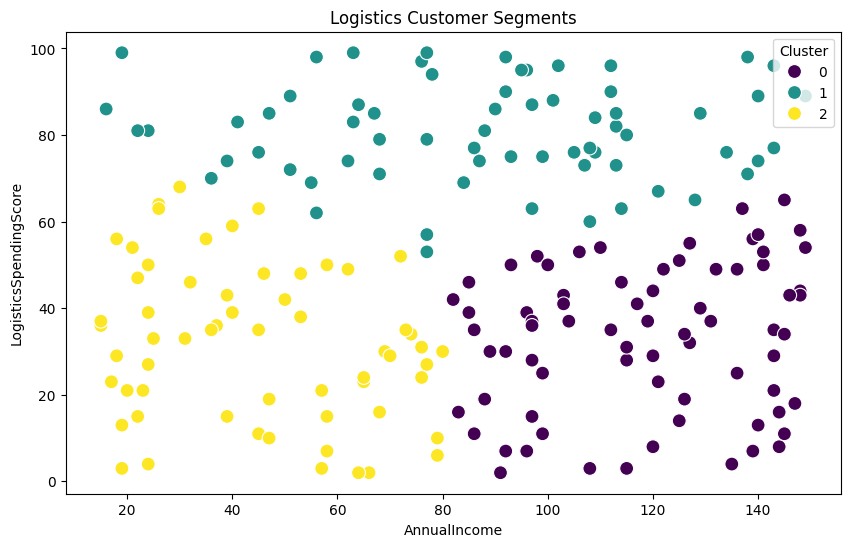

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Plotting the groups
sns.scatterplot(data=customer_df,
                x='AnnualIncome',
                y='LogisticsSpendingScore',
                hue='Cluster',
                palette='viridis',
                s=100)

plt.title('Logistics Customer Segments')
plt.show()

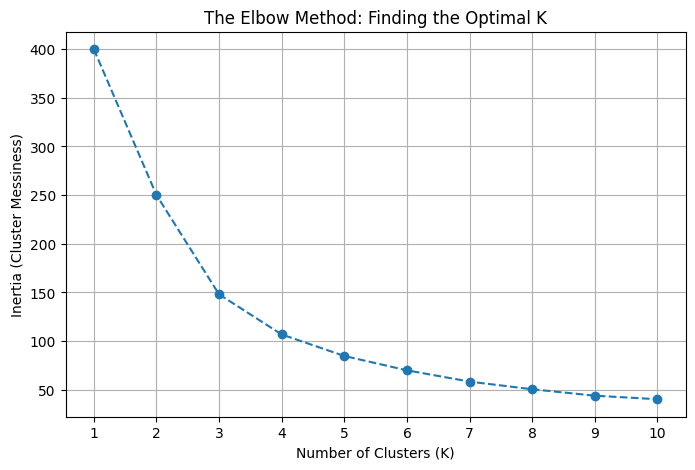

In [11]:
# elbow method

inertia_vals = []
k_range = range(1,11)

for k in k_range:
    test_kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    test_kmeans.fit(X_scaled)
    inertia_vals.append(test_kmeans.inertia_)


    # 3. Plot the results
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia_vals, marker='o', linestyle='--')
plt.title('The Elbow Method: Finding the Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Cluster Messiness)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [13]:
from sklearn.metrics import silhouette_score

for k in [3, 4, 5]:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"K={k} | Silhouette Score: {score:.4f}")



K=3 | Silhouette Score: 0.3938


NameError: name 'final_kmeans' is not defined

In [14]:
import joblib

joblib.dump(kmeans, 'logistics_cluster_model.pkl' )
joblib.dump(scalar, 'logistics_scaler.pkl')

print("Success! Your AI and Scaler are now saved as files.")

Success! Your AI and Scaler are now saved as files.
